In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore

## Load Dataset

In [2]:
df = pd.read_csv("Dataset.csv")

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.shape

(1200, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    str    
 12  ReferralSource   1200 non-null   str    
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), str(10)
memory usage: 226.8 KB


In [6]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
# df.describe(include="object")
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


## Exploratory Data Analysis (EDA)

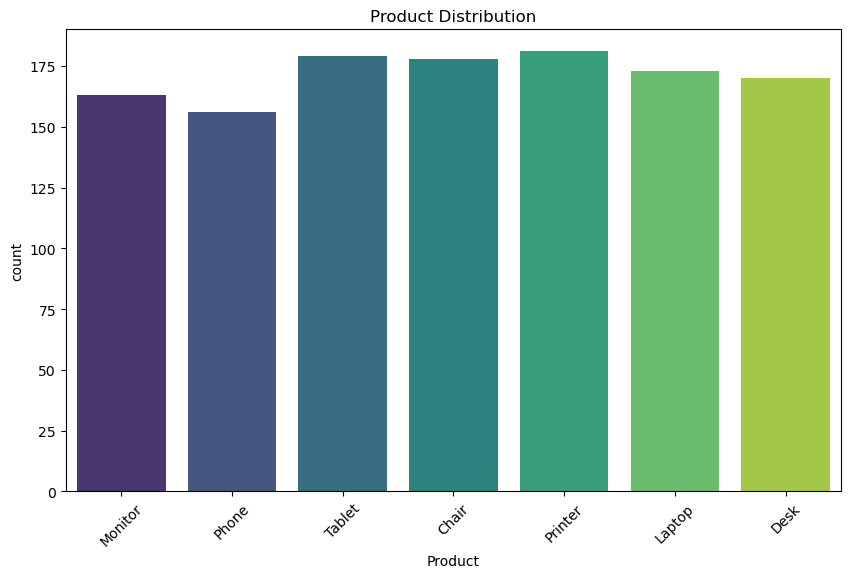

In [9]:
# Product Distribution Analysis

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Product', palette='viridis', hue="Product")
plt.title('Product Distribution')
plt.xticks(rotation=45)
plt.show()

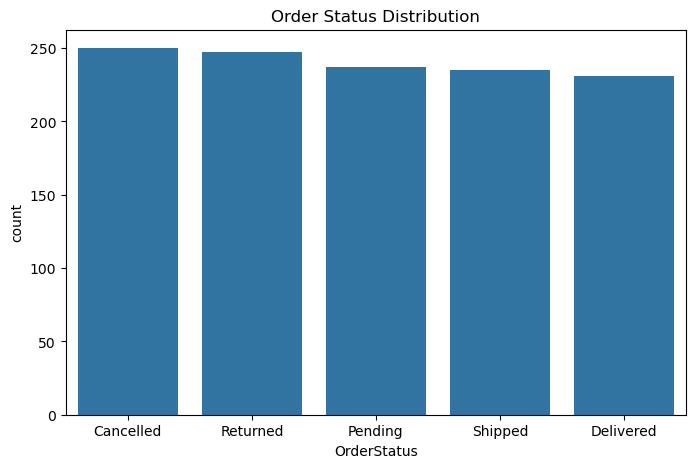

In [10]:
# Order status Analysis

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='OrderStatus',
    order=df['OrderStatus'].value_counts().index
)

plt.title('Order Status Distribution')

plt.show()

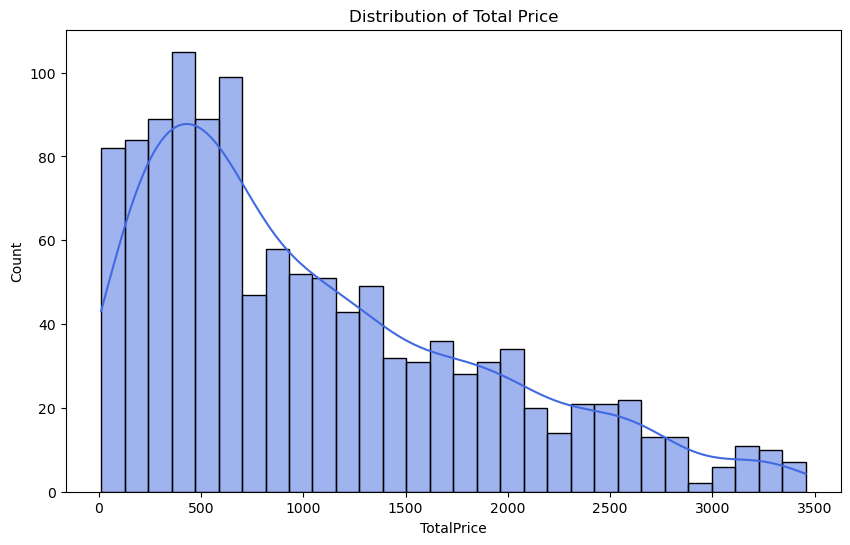

In [11]:
# Total Price Distribution

plt.figure(figsize=(10,6))
sns.histplot(
    df['TotalPrice'],
    bins=30,
    kde=True,
    color='royalblue'
)

plt.title('Distribution of Total Price')
plt.show()

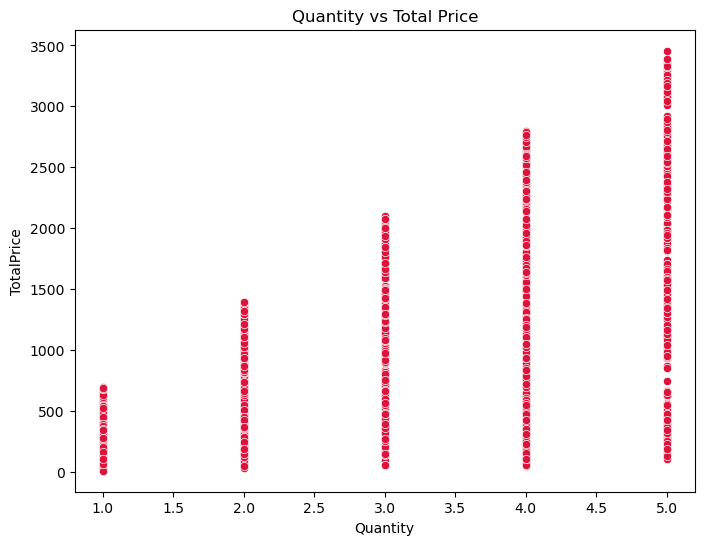

In [12]:
# Quantity vs Total Price

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='Quantity',
    y='TotalPrice',
    color='crimson'
)

plt.title('Quantity vs Total Price')

plt.show()

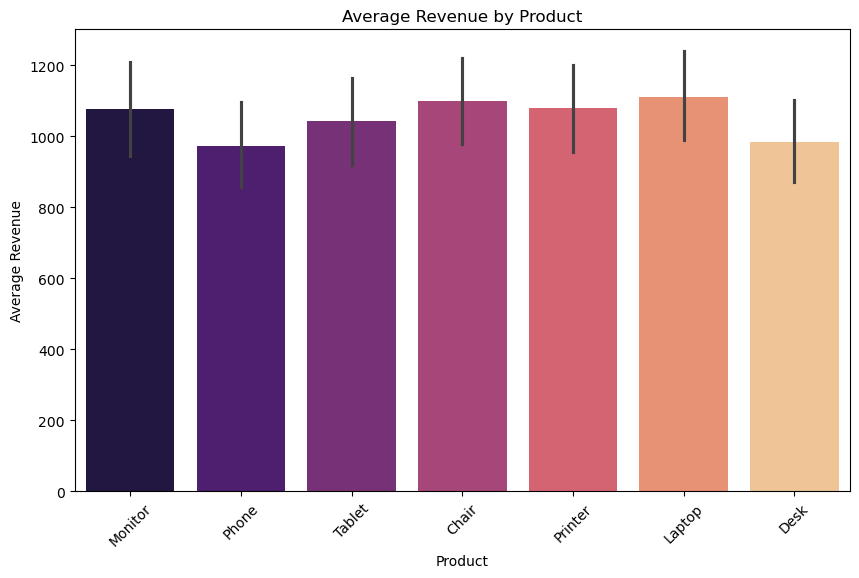

In [13]:
# Revenue by product

plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Product',
    y='TotalPrice',
    hue='Product',
    estimator=np.mean,
    palette='magma',
    legend=False
)

plt.title('Average Revenue by Product')
plt.xlabel('Product')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)

plt.show()

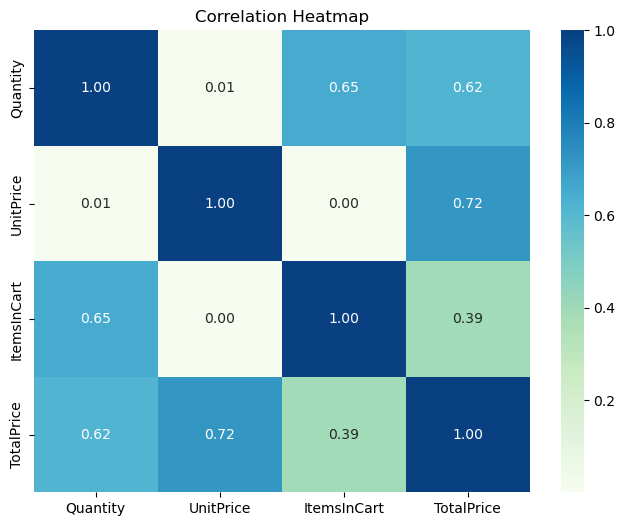

In [14]:
# Coorelation Analysis

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='GnBu',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

## Handle missing values

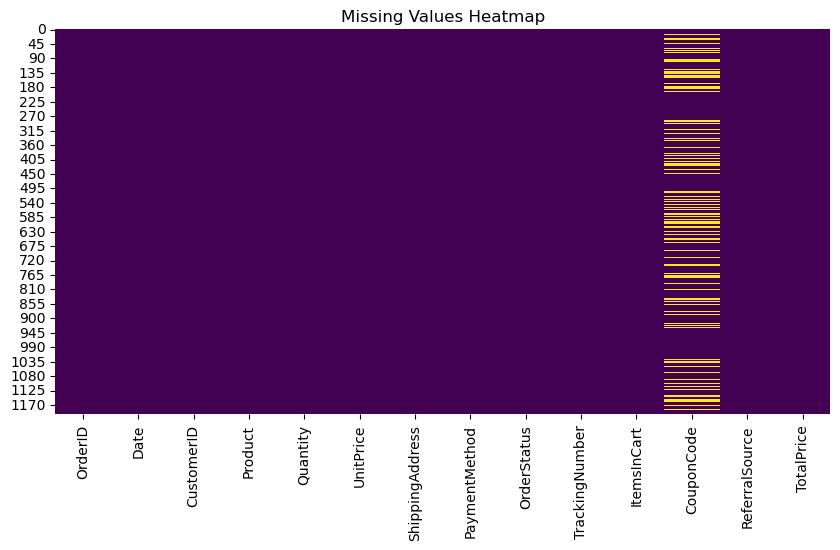

In [15]:
plt.figure(figsize=(10,5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title('Missing Values Heatmap')

plt.show()

In [16]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [17]:
df['CouponCode'].value_counts()

CouponCode
FREESHIP    313
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [18]:
df['CouponCode'] = df['CouponCode'].fillna(
    df['CouponCode'].mode()[0]
)

In [19]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [20]:
before_missing = 309
after_missing = df['CouponCode'].isnull().sum()

comparison = pd.DataFrame({
    'Stage':['Before Imputation','After Imputation'],
    'Missing Values':[before_missing, after_missing]
})

comparison

,Stage,Missing Values
0,Before Imputation,309
1,After Imputation,0


## Outlier Detection & Treatment

In [21]:
numeric_cols = [
    'Quantity',
    'UnitPrice',
    'ItemsInCart',
    'TotalPrice'
]

df[numeric_cols].describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


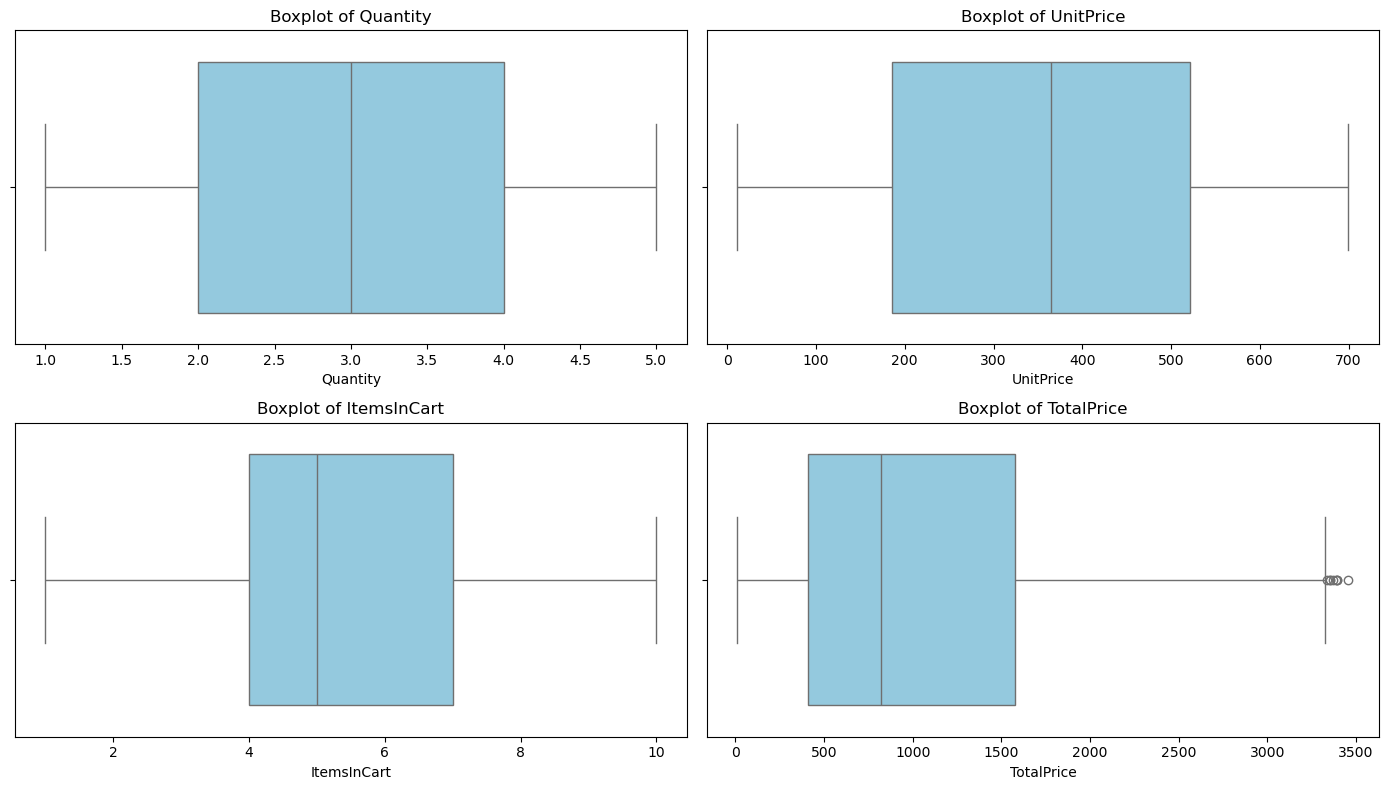

In [22]:
# Box Plot

plt.figure(figsize=(14,8))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,2,i)

    sns.boxplot(
        x=df[col],
        color='skyblue'
    )

    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### 1. IQR Method

In [23]:
def detect_iqr_outliers(data, column):

    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return len(outliers)

In [24]:
iqr_results = {}

for col in numeric_cols:
    iqr_results[col] = detect_iqr_outliers(df, col)

iqr_summary = pd.DataFrame(
    iqr_results.items(),
    columns=['Feature','IQR_Outliers']
)

iqr_summary

,Feature,IQR_Outliers
0,Quantity,0
1,UnitPrice,0
2,ItemsInCart,0
3,TotalPrice,8


### 2. Z-Score Method

In [25]:
from scipy.stats import zscore

In [26]:
def detect_zscore_outliers(data, column):

    z_scores = np.abs(
        zscore(data[column])
    )

    return np.sum(z_scores > 3)

In [27]:
zscore_results = {}

for col in numeric_cols:
    zscore_results[col] = detect_zscore_outliers(df, col)

zscore_summary = pd.DataFrame(
    zscore_results.items(),
    columns=['Feature','ZScore_Outliers']
)

zscore_summary

,Feature,ZScore_Outliers
0,Quantity,0
1,UnitPrice,0
2,ItemsInCart,0
3,TotalPrice,0


In [28]:
# Compare both methods

comparison = pd.merge(
    iqr_summary,
    zscore_summary,
    on='Feature'
)

comparison

,Feature,IQR_Outliers,ZScore_Outliers
0,Quantity,0,0
1,UnitPrice,0,0
2,ItemsInCart,0,0
3,TotalPrice,8,0


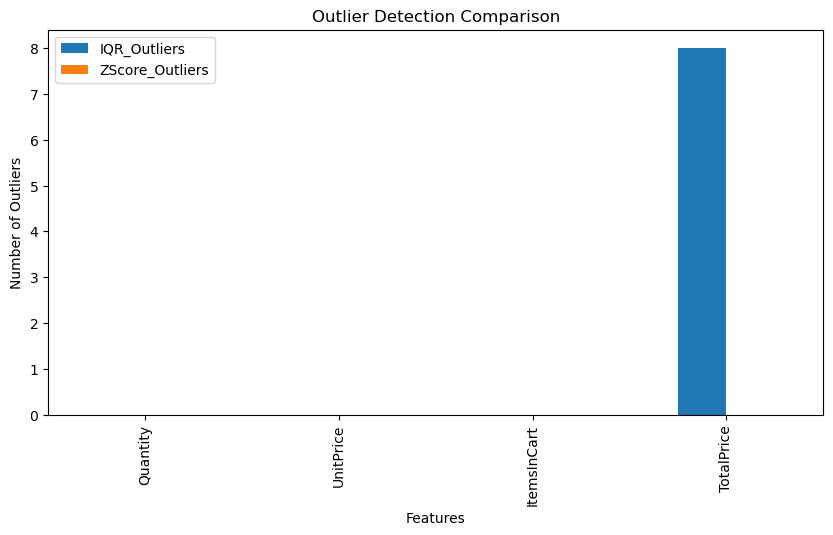

In [29]:
comparison.set_index('Feature').plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Outlier Detection Comparison')
plt.ylabel('Number of Outliers')
plt.xlabel('Features')

plt.show()

In [30]:
# Outliers treatment 
# Calculate boundaries

Q1 = df['TotalPrice'].quantile(0.25)
Q3 = df['TotalPrice'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -1341.4125
Upper Bound: 3330.4075


In [31]:
df['TotalPrice'] = np.where(
    df['TotalPrice'] > upper_bound,
    upper_bound,
    df['TotalPrice']
)

df['TotalPrice'] = np.where(
    df['TotalPrice'] < lower_bound,
    lower_bound,
    df['TotalPrice']
)

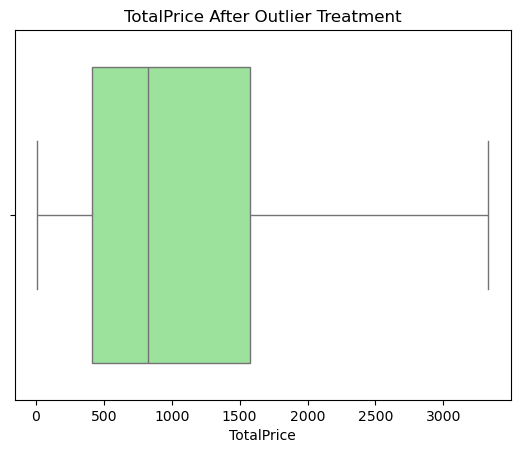

In [32]:
sns.boxplot(
    x=df['TotalPrice'],
    color='lightgreen'
)

plt.title('TotalPrice After Outlier Treatment')

plt.show()

In [33]:
detect_iqr_outliers(df, 'TotalPrice')

0

## Feature engineering

In [34]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [35]:
# Convert Date Column

df['Date'] = pd.to_datetime(df['Date'])

In [36]:
df['Date'].head()

0   2023-01-04
1   2024-08-23
2   2024-02-27
3   2023-10-15
4   2025-05-08
Name: Date, dtype: datetime64[us]

In [37]:
# Coupen used

df['CouponUsed'] = np.where(
    df['CouponCode'].notnull(),
    1,
    0
)

df[['CouponCode','CouponUsed']].head()

,CouponCode,CouponUsed
0,SAVE10,1
1,SAVE10,1
2,FREESHIP,1
3,SAVE10,1
4,SAVE10,1


In [38]:
# Price per item

df['PricePerItem'] = (
    df['TotalPrice'] /
    df['Quantity']
)

df[['Quantity','TotalPrice','PricePerItem']].head()

,Quantity,TotalPrice,PricePerItem
0,5,2853.10,570.62
1,2,302.70,151.35
2,5,2753.40,550.68
3,1,273.19,273.19
4,4,2504.04,626.01


In [39]:
# Order month 

df['OrderMonth'] = df['Date'].dt.month

df[['Date','OrderMonth']].head()

,Date,OrderMonth
0,2023-01-04,1
1,2024-08-23,8
2,2024-02-27,2
3,2023-10-15,10
4,2025-05-08,5


In [40]:
# Order year

df['OrderYear'] = df['Date'].dt.year

df[['Date','OrderYear']].head()

,Date,OrderYear
0,2023-01-04,2023
1,2024-08-23,2024
2,2024-02-27,2024
3,2023-10-15,2023
4,2025-05-08,2025


In [41]:
# Average cart value

df['AverageCartValue'] = (
    df['TotalPrice'] /
    df['ItemsInCart']
)

df[['ItemsInCart','TotalPrice','AverageCartValue']].head()

,ItemsInCart,TotalPrice,AverageCartValue
0,7,2853.10,407.585714
1,3,302.70,100.900000
2,8,2753.40,344.175000
3,5,273.19,54.638000
4,8,2504.04,313.005000


In [58]:
# Round engineered features

df['PricePerItem'] = df['PricePerItem'].round(2)

df['AverageCartValue'] = df['AverageCartValue'].round(2)

In [59]:
# Verify new features

new_features = [
    'CouponUsed',
    'PricePerItem',
    'OrderMonth',
    'OrderYear',
    'AverageCartValue'
]

df[new_features].head()

,CouponUsed,PricePerItem,OrderMonth,OrderYear,AverageCartValue
0,1,570.62,1,2023,407.59
1,1,151.35,8,2024,100.90
2,1,550.68,2,2024,344.18
3,1,273.19,10,2023,54.64
4,1,626.01,5,2025,313.00


In [60]:
df[new_features].describe()

,CouponUsed,PricePerItem,OrderMonth,OrderYear,AverageCartValue
count,1200.0,1200.000000,1200.000000,1200.000000,1200.000000
mean,1.0,356.347717,5.995000,2023.767500,207.677292
std,0.0,197.072452,3.344293,0.750942,154.144021
min,1.0,11.390000,1.000000,2023.000000,1.900000
25%,1.0,186.062500,3.000000,2023.000000,83.050000
50%,1.0,364.210000,6.000000,2024.000000,172.680000
75%,1.0,521.570000,9.000000,2024.000000,301.197500
max,1.0,699.930000,12.000000,2025.000000,697.930000


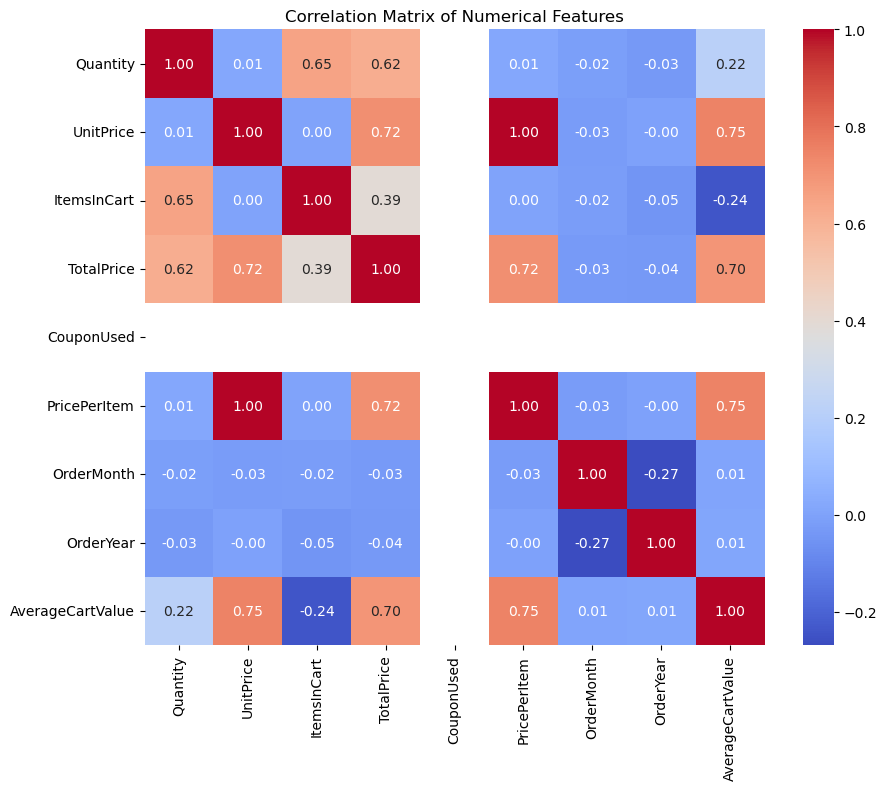

In [61]:
# Features Coorelation 

feature_cols = [
    'Quantity',
    'UnitPrice',
    'ItemsInCart',
    'TotalPrice',
    'CouponUsed',
    'PricePerItem',
    'OrderMonth',
    'OrderYear',
    'AverageCartValue'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[feature_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Features')

plt.show()

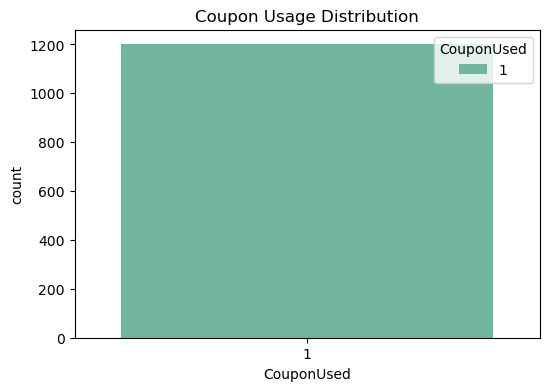

In [62]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='CouponUsed',
    data=df,
    palette='Set2',
    hue="CouponUsed"
)

plt.title('Coupon Usage Distribution')

plt.show()

## Remove Irrelevant Columns

In [63]:
columns_to_drop = [
    'OrderID',
    'CustomerID',
    'TrackingNumber',
    'ShippingAddress'
]

df.drop(
    columns=columns_to_drop,
    inplace=True
)

KeyError: "['OrderID', 'CustomerID', 'TrackingNumber', 'ShippingAddress'] not found in axis"

In [ ]:
df.columns

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

## Encoding 

In [ ]:
df.head()

In [64]:
df.shape

(1200, 15)

In [65]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['ReferralSource'] = le.fit_transform(
    df['ReferralSource']
)

In [66]:
mapping = pd.DataFrame({
    'Category': le.classes_,
    'Encoded_Value': range(len(le.classes_))
})

mapping

,Category,Encoded_Value
0,0,0
1,1,1
2,2,2
3,3,3
4,4,4


In [67]:
# One hot encoding

categorical_cols = [
    'Product',
    'PaymentMethod',
    'OrderStatus',
    'CouponCode'
]

df_encoded = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

In [68]:
bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = (
    df_encoded[bool_cols]
    .astype(int)
)

In [73]:
df_encoded.head()

,Date,Quantity,UnitPrice,ItemsInCart,ReferralSource,TotalPrice,CouponUsed,PricePerItem,OrderMonth,OrderYear,...,PaymentMethod_Credit Card,PaymentMethod_Debit Card,PaymentMethod_Gift Card,PaymentMethod_Online,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,CouponCode_SAVE10,CouponCode_WINTER15
0,2023-01-04,5,570.62,7,3,2853.10,1,570.62,1,2023,...,0,1,0,0,0,0,0,1,1,0
1,2024-08-23,2,151.35,3,4,302.70,1,151.35,8,2024,...,0,0,0,1,0,0,0,1,1,0
2,2024-02-27,5,550.68,8,0,2753.40,1,550.68,2,2024,...,1,0,0,0,0,0,0,0,0,0
3,2023-10-15,1,273.19,5,1,273.19,1,273.19,10,2023,...,0,1,0,0,0,0,1,0,1,0
4,2025-05-08,4,626.01,8,0,2504.04,1,626.01,5,2025,...,0,0,0,1,1,0,0,0,1,0


In [70]:
quality_report = pd.DataFrame({

    'Metric':[
        'Rows',
        'Columns',
        'Missing Values',
        'Duplicate Rows'
    ],

    'Value':[
        df_encoded.shape[0],
        df_encoded.shape[1],
        df_encoded.isnull().sum().sum(),
        df_encoded.duplicated().sum()
    ]

})

quality_report

,Metric,Value
0,Rows,1200
1,Columns,27
2,Missing Values,0
3,Duplicate Rows,0


### Save final dataset

In [71]:
df_encoded.to_csv(
    'Cleaned_Dataset.csv',
    index=False
)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully
